In [ ]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\ASUS  TUF\AppData\Local\Programs\Python\Python312\python.exe
3.12.7 (tags/v3.12.7:0b05ead, Oct  1 2024, 03:06:41) [MSC v.1941 64 bit (AMD64)]


In [2]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device available")

2.11.0+cu128
True
12.8
NVIDIA GeForce RTX 5050 Laptop GPU


In [3]:
import torch

print(torch.cuda.get_device_name(0))
print(torch.version.cuda)
print(torch.cuda.device_count())

NVIDIA GeForce RTX 5050 Laptop GPU
12.8
1


In [4]:
import torch
from transformers import MarianMTModel, MarianTokenizer

device = torch.device("cuda")

model_name = 'Helsinki-NLP/opus-mt-en-de'
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name).to(device)

text = "こんにちは"

inputs = tokenizer(text, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model.generate(**inputs)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

c:\Users\ASUS  TUF\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

ENTWICKLUNG UND ENTWICKLUNG DER ENTWICKLUNG


In [5]:
import torch

print(torch.__version__)
print(torch.version.cuda)

print(torch.cuda.is_available())

x = torch.randn(2,2, device="cuda")
y = torch.randn(2,2, device="cuda")
print(x @ y)

2.11.0+cu128
12.8
True
tensor([[-0.6976, -0.2007],
        [-1.1809,  0.0603]], device='cuda:0')


In [1]:
import pandas as pd
import torch
from transformers import MarianMTModel, MarianTokenizer
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available()else "cpu")
print("Device:", device)
MODEL_JA_EN = "Helsinki-NLP/opus-mt-ja-en"
MODEL_EN_ID = "Helsinki-NLP/opus-mt-en-id"
print("Loading JA -> EN model...")
tokenizer_ja_en = MarianTokenizer.from_pretrained(MODEL_JA_EN)
model_ja_en = MarianMTModel.from_pretrained(MODEL_JA_EN).to(device)
print("Loading EN -> ID Model...")
tokenizer_en_id = MarianTokenizer.from_pretrained(MODEL_EN_ID)
model_en_id = MarianMTModel.from_pretrained(MODEL_EN_ID).to(device)
print("Models loaded successfully")

df = pd.read_csv("japanese_lemmas.csv")

texts = df["lemma"].astype(str).tolist()
print("Jumlah data:", len(texts))
def translate_batch_ja_to_id(texts, batch_size=16):
    translated_texts =  []

    for i in tqdm(range(0, len(texts), batch_size)):
        batch = texts[i:i + batch_size]

        inputs_ja_en = tokenizer_ja_en(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=64
        ).to(device)

        with torch.no_grad():
            outputs_ja_en = model_ja_en.generate(**inputs_ja_en)

        en_texts = tokenizer_ja_en.batch_decode(
            outputs_ja_en,
            skip_special_tokens=True
        )
        input_en_id = tokenizer_en_id(
            en_texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=64
        ).to(device)

        with torch.no_grad():
            outputs_en_id = model_en_id.generate(**input_en_id)

        id_texts = tokenizer_en_id.batch_decode(
            outputs_en_id,
            skip_special_tokens=True
        )
        translated_texts.extend(id_texts)

    return translated_texts

df["indonesia"] = translate_batch_ja_to_id(texts)
df.to_csv("hasil_terjemahan.csv", index=False)
print("Selesai! File tersimpan")

Device: cuda
Loading JA -> EN model...


c:\Users\ASUS  TUF\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\models\marian\tokenization_marian.py:176: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading EN -> ID Model...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Models loaded successfully
Jumlah data: 15000


100%|██████████| 938/938 [13:52<00:00,  1.13it/s]  


Selesai! File tersimpan


Data Awal:
   rank  frequency lemma indonesia
0     1   41309.50     の         .
1     2   23509.54     に         !
2     3   22216.80     は      Huh.
3     4   20431.93     て         .
4     5   20326.59     を   Mm-hmm.

Data setelah pembersihan:
   rank  frequency lemma indonesia
0     1   41309.50     の         .
1     2   23509.54     に         !
2     3   22216.80     は      Huh.
3     4   20431.93     て         .
4     5   20326.59     を   Mm-hmm.
Jumlah data setelah cleaning: 15000

Data setelah feature engineering:
  lemma  lemma_length  kanji_ratio
0     の             1          0.0
1     に             1          0.0
2     は             1          0.0
3     て             1          0.0
4     を             1          0.0

Data setelah dinormalisasi:
[[-1.73193534 64.34474646 -1.3239649  -1.39572724]
 [-1.7317044  36.58394989 -1.3239649  -1.39572724]
 [-1.73147346 34.56779412 -1.3239649  -1.39572724]
 [-1.73124252 31.78411298 -1.3239649  -1.39572724]
 [-1.73101158 31.61982484 -1

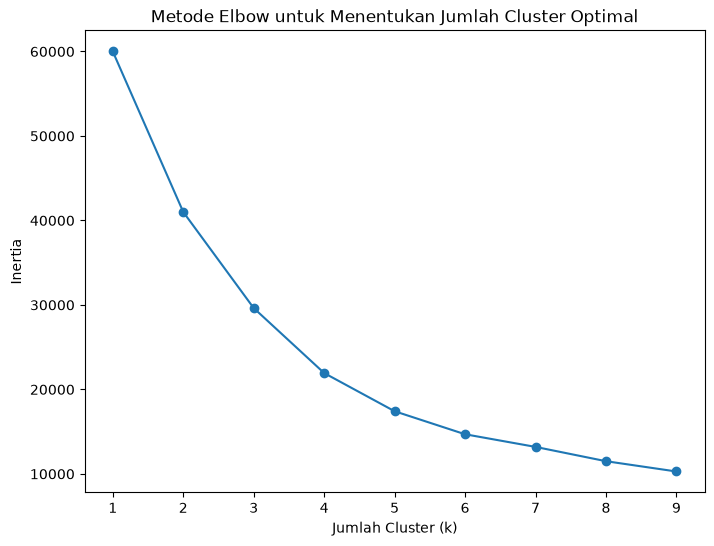


Evaluasi Clustering:
Silhouette Score: 0.3872770523877982
Davies-Bouldin Index: 0.7287944630032467

Hasil cluster:
     lemma  rank  frequency  lemma_length  kanji_ratio  cluster
0        の     1   41309.50             1          0.0        3
1        に     2   23509.54             1          0.0        3
2        は     3   22216.80             1          0.0        3
3        て     4   20431.93             1          0.0        3
4        を     5   20326.59             1          0.0        3
10      ます    11    9604.49             2          0.0        0
11       で    12    9537.75             1          0.0        0
12      ない    13    8189.00             2          0.0        0
13      いる    14    8140.22             2          0.0        0
14       も    15    7900.34             1          0.0        0
42     という    43    2190.45             3          0.0        1
62     できる    63    1437.45             3          0.0        1
73     として    74    1186.32             3          0

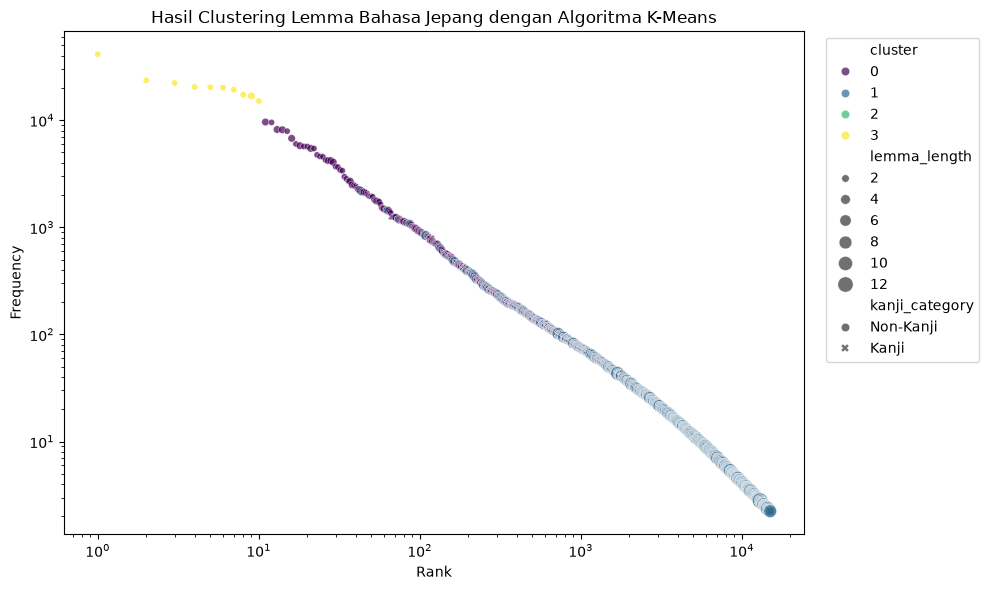


Statistik tiap cluster:
                 rank                        frequency                      \
                 mean   min    max count          mean       min       max   
cluster                                                                      
0         3300.785993    11   8393  5126     92.424421      5.45   9604.49   
1         8344.423570    43  15000  4913     15.112892      2.24   2190.45   
2        11026.350838  6670  14997  4951      3.934029      2.24      7.65   
3            5.500000     1     10    10  21636.942000  15095.29  41309.50   

              kanji_ratio                 cluster                
        count        mean  min  max count    mean min max count  
cluster                                                          
0        5126    0.817775  0.0  1.0  5126     0.0   0   0  5126  
1        4913    0.082590  0.0  1.0  4913     1.0   1   1  4913  
2        4951    0.945264  0.0  1.0  4951     2.0   2   2  4951  
3          10    0.000000  0.0  

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import silhouette_score, davies_bouldin_score

df = pd.read_csv("hasil_terjemahan.csv")

print("Data Awal:")
print(df.head())

df = df.drop_duplicates()
df = df.dropna(subset=["lemma", "rank", "frequency"])

df["rank"] = pd.to_numeric(df["rank"], errors="coerce")
df["frequency"] = pd.to_numeric(df["frequency"], errors="coerce")

df = df.dropna(subset=["rank", "frequency"])

print("\nData setelah pembersihan:")
print(df.head())
print("Jumlah data setelah cleaning:", len(df))

df["lemma_length"] = df["lemma"].apply(len)

# Kanji Ratio
def kanji_ratio(text):
    kanji = re.findall(r'[\u4e00-\u9faf]', str(text))
    return len(kanji) / len(text) if len(text) > 0 else 0

df["kanji_ratio"] = df["lemma"].apply(kanji_ratio)

print("\nData setelah feature engineering:")
print(df[["lemma","lemma_length","kanji_ratio"]].head())

X = df[["rank", "frequency", "lemma_length", "kanji_ratio"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData setelah dinormalisasi:")
print(X_scaled[:5])

inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(K, inertia, marker='o')
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.title("Metode Elbow untuk Menentukan Jumlah Cluster Optimal")
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

sil_score = silhouette_score(X_scaled, clusters)
dbi_score = davies_bouldin_score(X_scaled, clusters)

print("\nEvaluasi Clustering:")
print("Silhouette Score:", sil_score)
print("Davies-Bouldin Index:", dbi_score)

print("\nHasil cluster:")
print(df.groupby("cluster").head(5)[["lemma", "rank", "frequency", "lemma_length", "kanji_ratio", "cluster"]])

df["kanji_category"] = df["kanji_ratio"].apply(lambda x: "Kanji" if x > 0 else "Non-Kanji")

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="rank",
    y="frequency",
    hue="cluster",
    size="lemma_length",
    style="kanji_category",
    sizes=(20,120),
    palette="viridis",
    alpha=0.7
)
plt.xscale("log")
plt.yscale("log")
plt.title("Hasil Clustering Lemma Bahasa Jepang dengan Algoritma K-Means")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.legend(title="Cluster")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

cluster_stats = df.groupby("cluster")[["rank", "frequency", "kanji_ratio", "cluster"]].agg(
    ["mean", "min", "max", "count"]
)

print("\nStatistik tiap cluster:")
print(cluster_stats)

for c in sorted(df["cluster"].unique()):
    print(f"\nCluster {c} - contoh lemma:")
    print(df[df["cluster"] == c].head(5)[["lemma", "rank", "frequency", "kanji_ratio", "cluster"]])

df.to_csv("clustered_japanese_lemmas.csv", index=False)
print("\nHasil clustering disimpan ke 'clustered_japanese_lemmas.csv'") 
#oi#